# IEM Cologne 2026 — Model Analysis

Visualises training data, feature importance, model performance, and tournament simulation results.

**Run `train.py` first** to generate the artefacts in `data/` and `models/`.

---

### Contents
1. [Load Artefacts](#1-load-artefacts)
2. [Data Overview](#2-data-overview)
   - 2.1 Matches per Quarter
   - 2.2 Match Type Distribution
   - 2.3 Train / Val / Test Split
3. [Feature Analysis](#3-feature-analysis)
   - 3.1 Top-25 Feature Importances
   - 3.2 Correlation Heatmap
   - 3.3 ELO Differential by Outcome
4. [ELO Analysis](#4-elo-analysis)
   - 4.1 ELO Over Time
   - 4.2 Final ELO Distribution
5. [Model Performance](#5-model-performance)
   - 5.1 Test Set Metrics
   - 5.2 ROC & Calibration Curves
   - 5.3 Predicted Probability Distribution
6. [Tournament Simulation Results](#6-tournament-simulation-results)
   - 6.1 Champion Probability Bar Chart
   - 6.2 Stage Probability Heatmap
   - 6.3 Stage Breakdown — All Teams

## 1. Load Artefacts

In [15]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from o1_config import DATA_DIR, MODEL_DIR, TRAIN_END_DATE, VAL_END_DATE, ALL_TEAMS
from o3_features import feature_columns
from o4_neural_net import MatchPredictor, pytorch_predict

sns.set_theme(style="darkgrid", palette="deep")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

In [16]:
training_df = pd.read_parquet(DATA_DIR / "training_data.parquet")
raw_df      = pd.read_parquet(DATA_DIR / "raw_matches.parquet")
feat_imp    = pd.read_csv(DATA_DIR / "feature_importance.csv")

feat_cols   = pickle.load(open(MODEL_DIR / "feature_cols.pkl", "rb"))
scaler      = pickle.load(open(MODEL_DIR / "scaler.pkl",       "rb"))
elo         = pickle.load(open(MODEL_DIR / "elo.pkl",          "rb"))
blend_w     = pickle.load(open(MODEL_DIR / "blend_weight.pkl", "rb"))
input_dim   = pickle.load(open(MODEL_DIR / "input_dim.pkl",    "rb"))

pt_model = MatchPredictor(input_dim)
pt_model.load_state_dict(torch.load(MODEL_DIR / "pytorch_model.pt", map_location="cpu"))
pt_model.eval()

xgb_model = XGBClassifier()
xgb_model.load_model(str(MODEL_DIR / "xgb_model.json"))

print(f"Loaded {len(training_df):,} training rows, {len(feat_cols)} features")
print(f"Blend: {blend_w:.0%} PyTorch + {1-blend_w:.0%} XGBoost")

Loaded 2,456 training rows, 114 features
Blend: 100% PyTorch + 0% XGBoost


## 2. Data Overview

### 2.1 Matches per Quarter · 2.2 Match Type Distribution · 2.3 Train / Val / Test Split

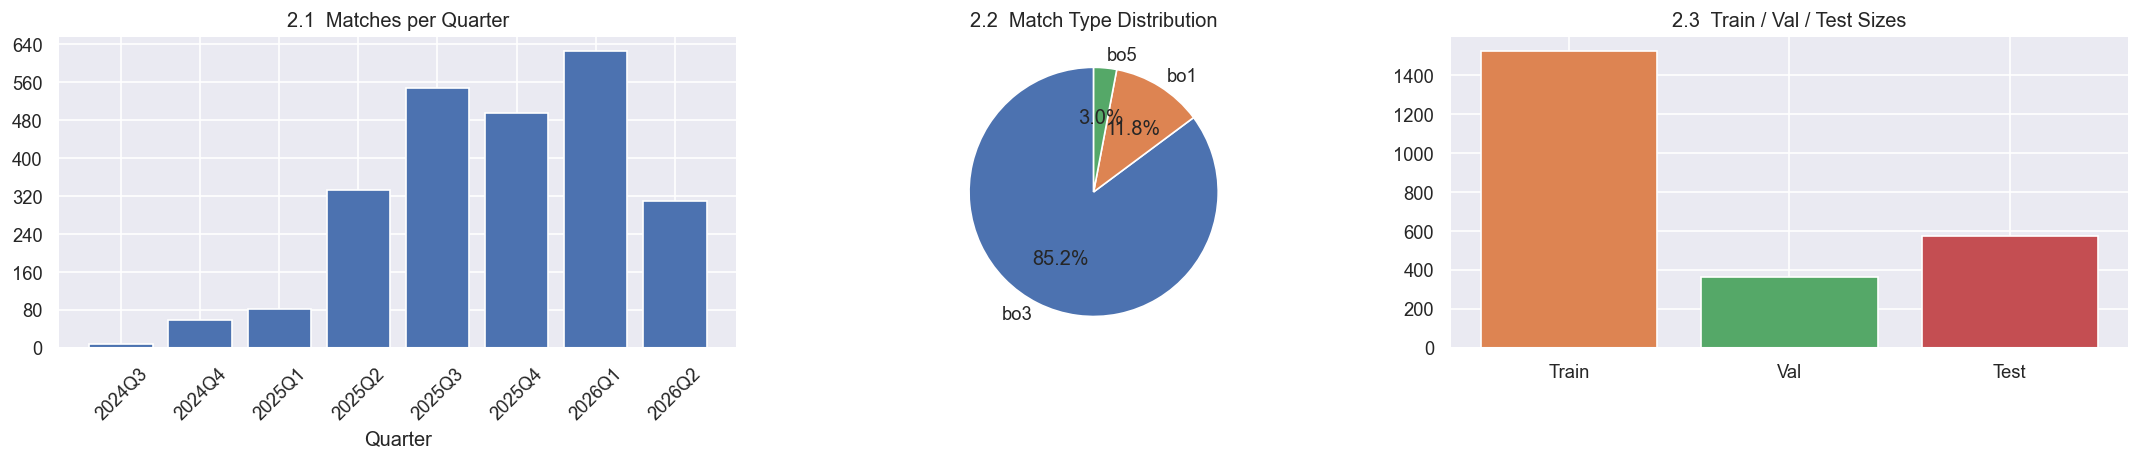

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 2.1 Matches per quarter
raw_df["quarter"] = raw_df["match_date"].dt.to_period("Q").astype(str)
cnt = raw_df.groupby("quarter").size()
axes[0].bar(cnt.index, cnt.values, color=sns.color_palette()[0])
axes[0].set_title("2.1  Matches per Quarter")
axes[0].set_xlabel("Quarter")
axes[0].tick_params(axis="x", rotation=45)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# 2.2 Match type distribution
mt = raw_df["match_type"].value_counts()
axes[1].pie(mt.values, labels=mt.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("2.2  Match Type Distribution")

# 2.3 Train / Val / Test split sizes
splits = {
    "Train": (training_df["match_date"] <= TRAIN_END_DATE).sum(),
    "Val":   ((training_df["match_date"] > TRAIN_END_DATE) & (training_df["match_date"] <= VAL_END_DATE)).sum(),
    "Test":  (training_df["match_date"] > VAL_END_DATE).sum(),
}
axes[2].bar(splits.keys(), splits.values(), color=sns.color_palette()[1:4])
axes[2].set_title("2.3  Train / Val / Test Sizes")
axes[2].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 3. Feature Analysis

### 3.1 Top-25 Feature Importances (XGBoost)

C:\Users\zp123_2zkvvkz\AppData\Local\Temp\ipykernel_81576\64028526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top25, y="feature", x="importance", ax=ax, palette="viridis")


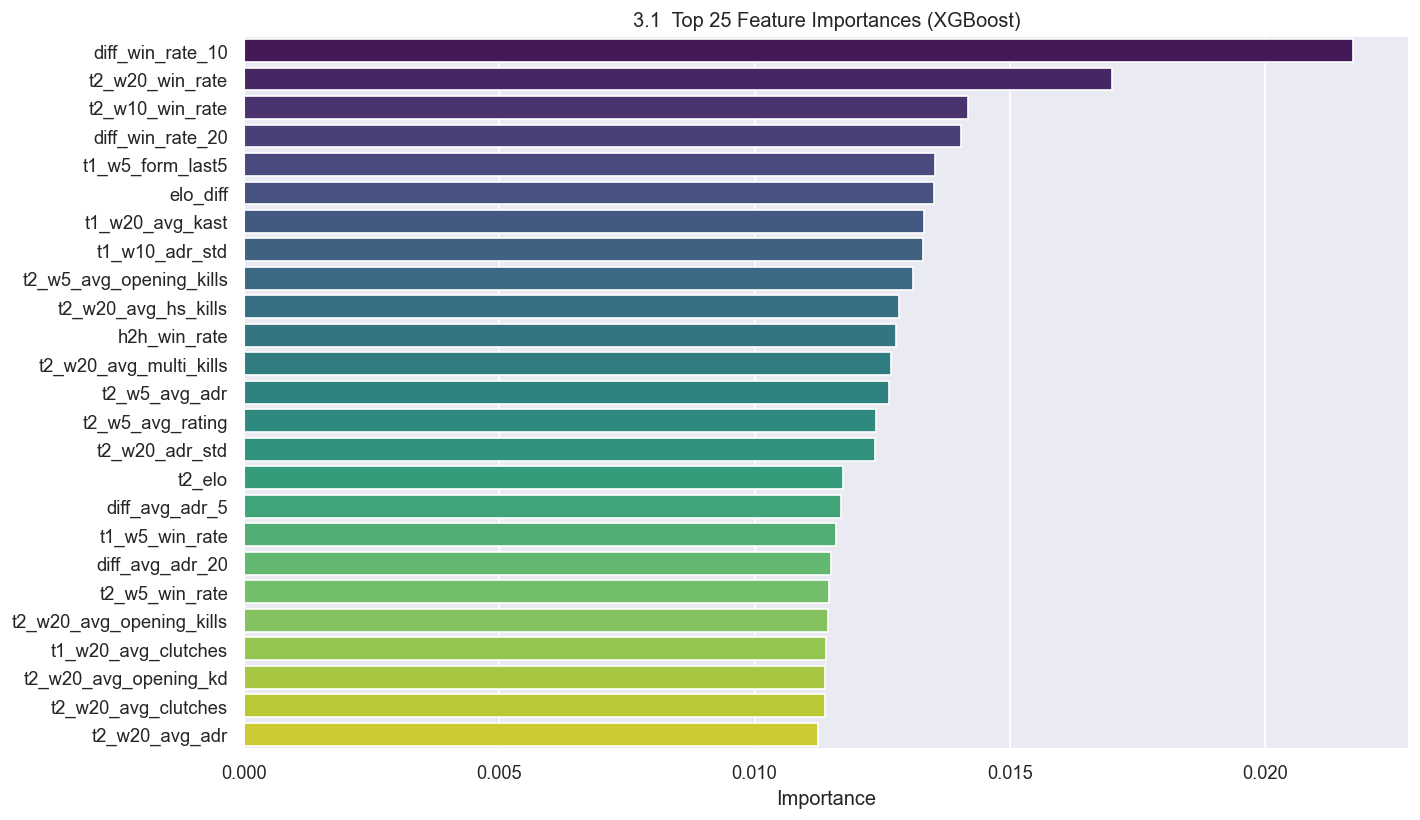

In [18]:
top25 = feat_imp.head(25)
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top25, y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("3.1  Top 25 Feature Importances (XGBoost)")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 3.2 Correlation Heatmap (Top 20 Features + Label)

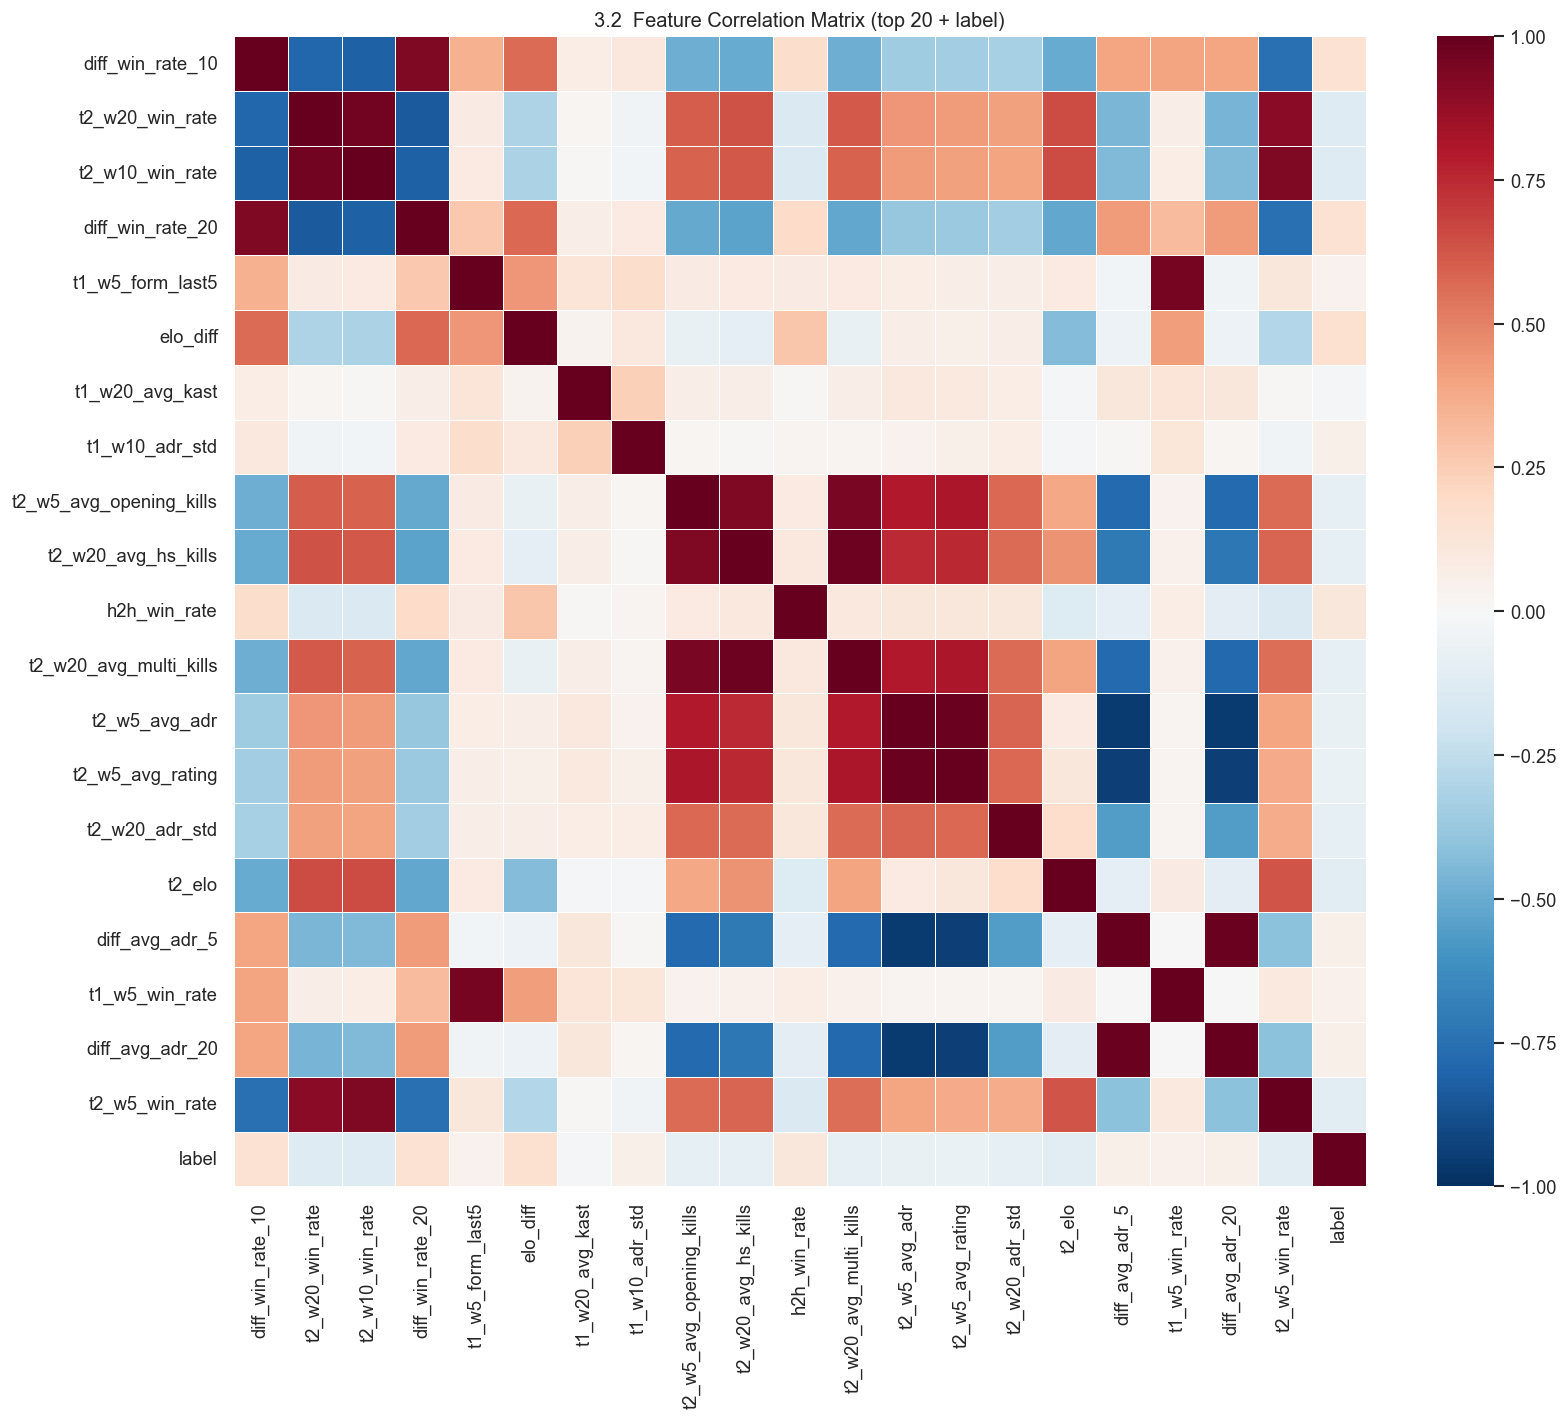

In [19]:
top20_feats = feat_imp["feature"].head(20).tolist()
corr_cols   = [c for c in top20_feats if c in training_df.columns] + ["label"]
corr_df     = training_df[corr_cols].copy().fillna(0)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_df.corr(),
    annot=False, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.3,
)
ax.set_title("3.2  Feature Correlation Matrix (top 20 + label)")
plt.tight_layout()
plt.show()

### 3.3 ELO Differential Distribution by Outcome

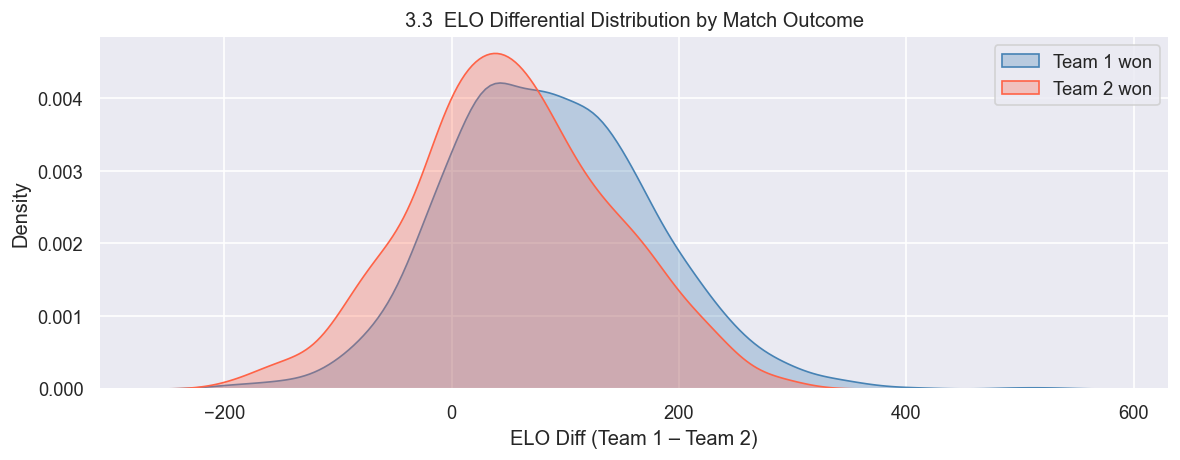

In [20]:
if "elo_diff" in training_df.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    for label, color, name in [(1, "steelblue", "Team 1 won"), (0, "tomato", "Team 2 won")]:
        subset = training_df[training_df["label"] == label]["elo_diff"].dropna()
        sns.kdeplot(subset, ax=ax, label=name, color=color, fill=True, alpha=0.3)
    ax.set_title("3.3  ELO Differential Distribution by Match Outcome")
    ax.set_xlabel("ELO Diff (Team 1 – Team 2)")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4. ELO Analysis

### 4.1 ELO Rating Over Time (Top 8 Teams)

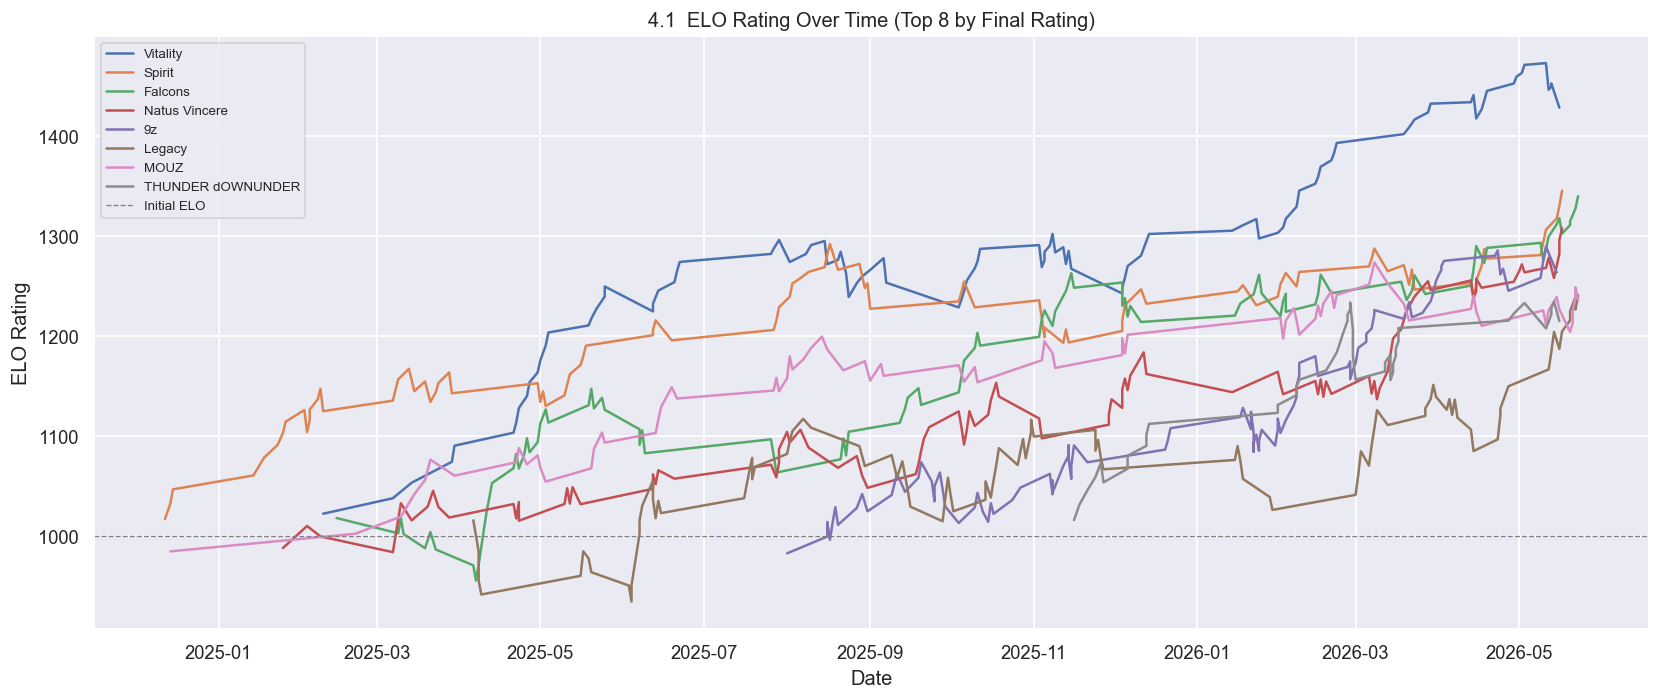

In [21]:
top_teams = sorted(elo.ratings, key=lambda t: elo.ratings[t], reverse=True)[:8]

fig, ax = plt.subplots(figsize=(14, 6))
for team in top_teams:
    history = elo.history.get(team, [])
    if not history:
        continue
    dates   = [d for d, _ in history]
    ratings = [r for _, r in history]
    ax.plot(dates, ratings, label=team, linewidth=1.5)

ax.axhline(1000, color="gray", linestyle="--", linewidth=0.8, label="Initial ELO")
ax.set_title("4.1  ELO Rating Over Time (Top 8 by Final Rating)")
ax.set_xlabel("Date")
ax.set_ylabel("ELO Rating")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 4.2 Final ELO Distribution Across All Teams

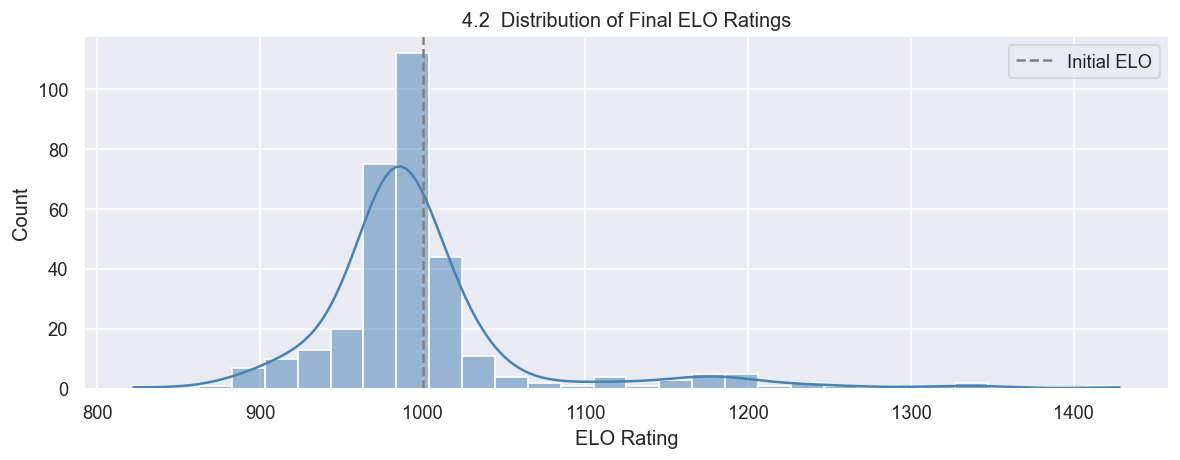

In [22]:
final_elos = pd.Series(dict(elo.ratings)).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(final_elos.values, bins=30, kde=True, ax=ax, color="steelblue")
ax.axvline(1000, color="gray", linestyle="--", label="Initial ELO")
ax.set_title("4.2  Distribution of Final ELO Ratings")
ax.set_xlabel("ELO Rating")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Model Performance

### 5.1 Test Set Metrics

In [23]:
test_df = training_df[training_df["match_date"] > VAL_END_DATE].copy()
X_te    = test_df[feat_cols].fillna(0).values.astype(np.float32)
y_te    = test_df["label"].values.astype(np.float32)

X_te_s = np.nan_to_num(scaler.transform(X_te)).astype(np.float32)

pt_probs  = pytorch_predict(pt_model, X_te_s)
xgb_probs = xgb_model.predict_proba(X_te_s)[:, 1]
ens_probs = blend_w * pt_probs + (1 - blend_w) * xgb_probs

print(f"Test size    : {len(y_te):,}")
print(f"PyTorch AUC  : {roc_auc_score(y_te, pt_probs):.4f}")
print(f"XGBoost AUC  : {roc_auc_score(y_te, xgb_probs):.4f}")
print(f"Ensemble AUC : {roc_auc_score(y_te, ens_probs):.4f}")

Test size    : 571
PyTorch AUC  : 0.6227
XGBoost AUC  : 0.5977
Ensemble AUC : 0.6227


### 5.2 ROC Curves & Calibration

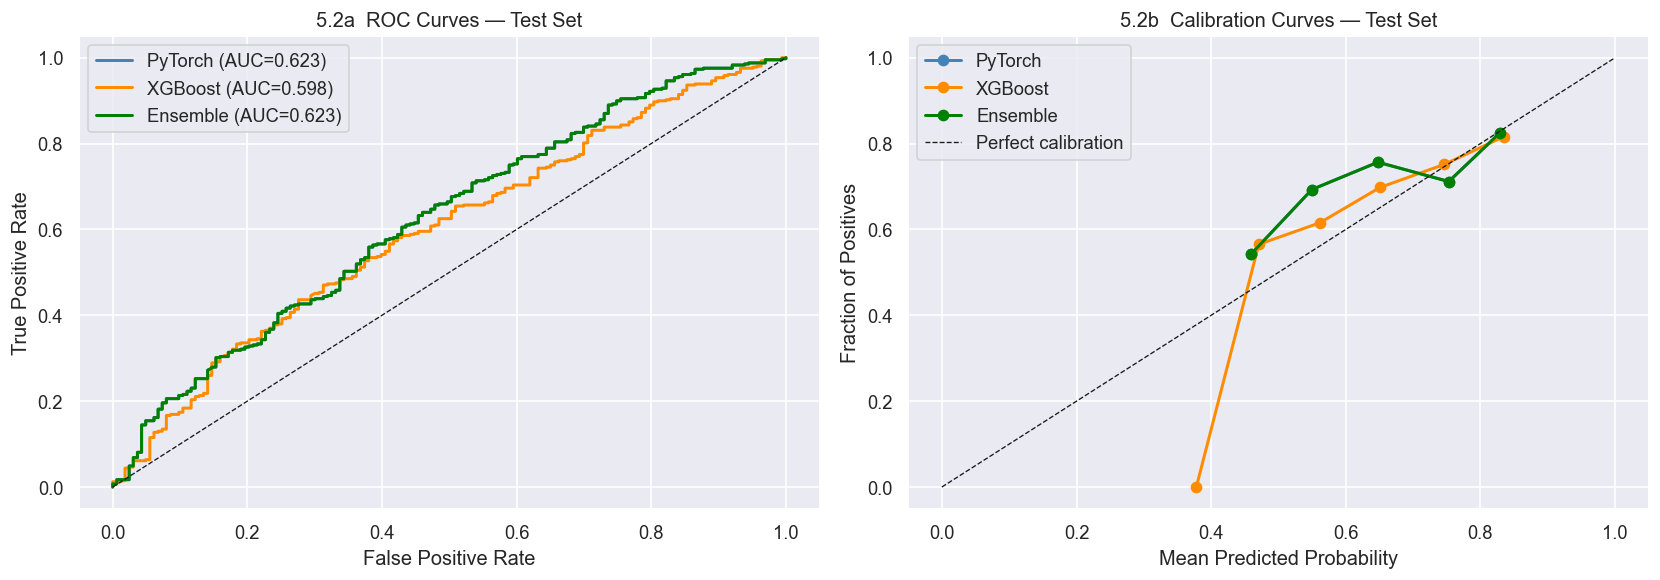

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, probs, color in [
    ("PyTorch",  pt_probs,  "steelblue"),
    ("XGBoost",  xgb_probs, "darkorange"),
    ("Ensemble", ens_probs, "green"),
]:
    fpr, tpr, _ = roc_curve(y_te, probs)
    auc = roc_auc_score(y_te, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=1.8)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_title("5.2a  ROC Curves — Test Set")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for name, probs, color in [
    ("PyTorch",  pt_probs,  "steelblue"),
    ("XGBoost",  xgb_probs, "darkorange"),
    ("Ensemble", ens_probs, "green"),
]:
    frac_pos, mean_pred = calibration_curve(y_te, probs, n_bins=10)
    axes[1].plot(mean_pred, frac_pos, marker="o", label=name, color=color, linewidth=1.8)

axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Perfect calibration")
axes[1].set_title("5.2b  Calibration Curves — Test Set")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Fraction of Positives")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.3 Predicted Probability Distribution by Outcome

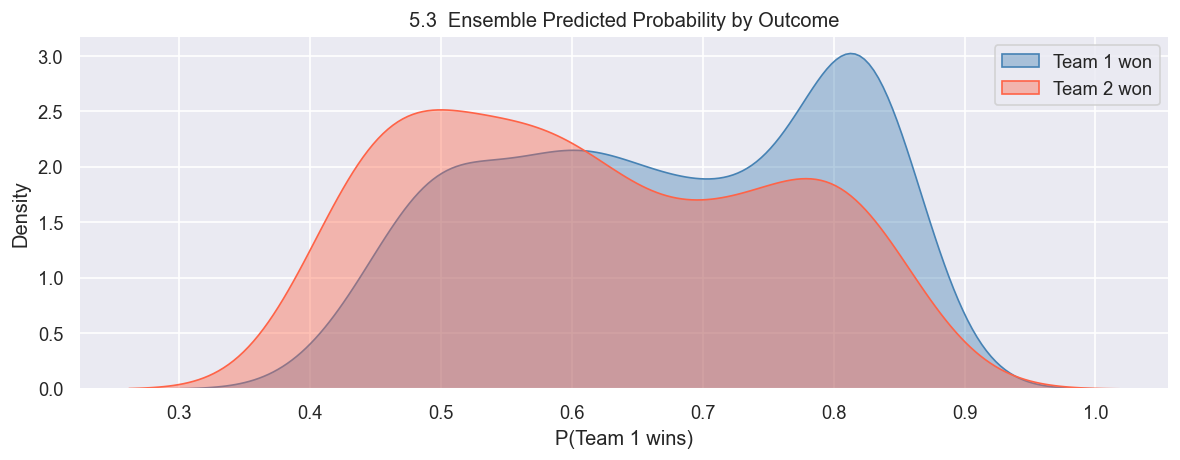

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(1, "steelblue", "Team 1 won"), (0, "tomato", "Team 2 won")]:
    mask = y_te == label
    sns.kdeplot(ens_probs[mask], ax=ax, fill=True, alpha=0.4, label=name, color=color)
ax.set_title("5.3  Ensemble Predicted Probability by Outcome")
ax.set_xlabel("P(Team 1 wins)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Tournament Simulation Results

Run `python simulate.py --tournament --n 50000` first to generate `data/tournament_odds.csv`.

### 6.1 Champion Probability Bar Chart

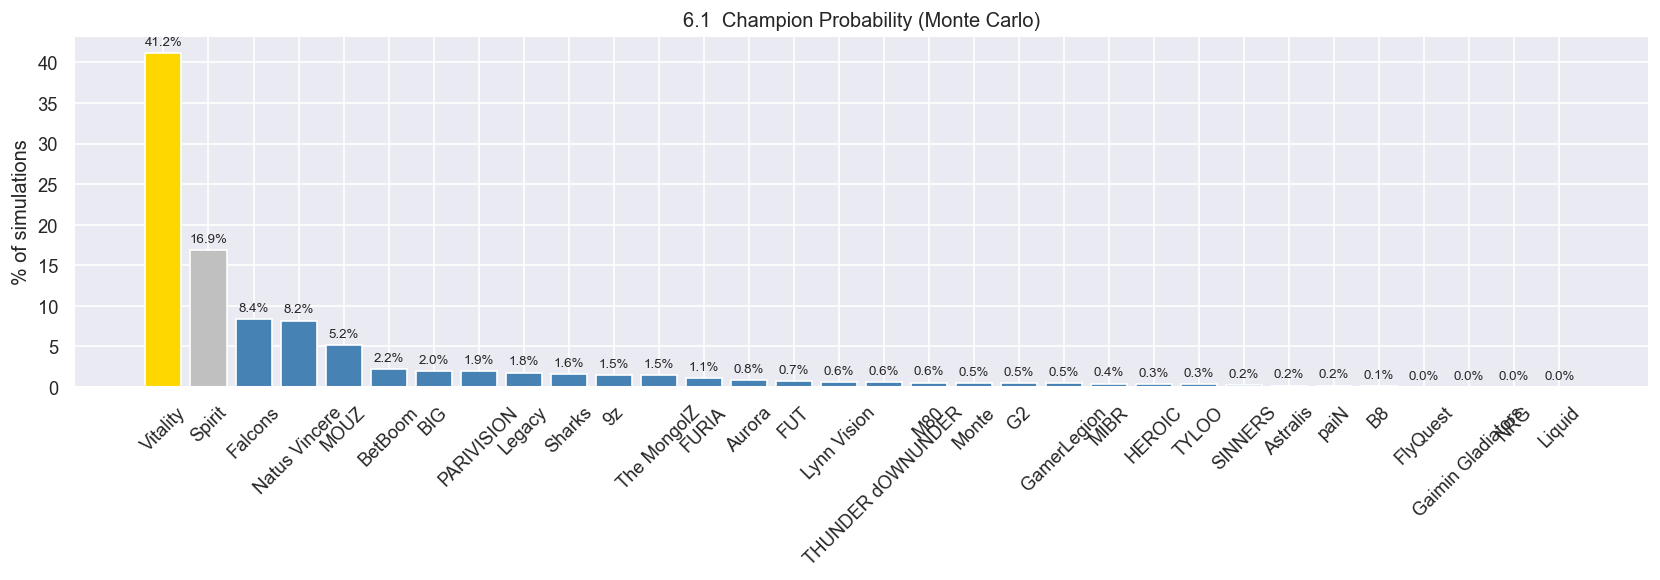

In [26]:
odds_path = DATA_DIR / "tournament_odds.csv"

if not odds_path.exists():
    print("tournament_odds.csv not found — run simulate.py --tournament first")
else:
    odds = pd.read_csv(odds_path).set_index("team")
    odds_sorted = odds.sort_values("champion_pct", ascending=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = [
        "gold"      if i == 0 else
        "silver"    if i == 1 else
        "steelblue"
        for i in range(len(odds_sorted))
    ]
    bars = ax.bar(odds_sorted.index, odds_sorted["champion_pct"], color=colors)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_title("6.1  Champion Probability (Monte Carlo)")
    ax.set_ylabel("% of simulations")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

### 6.2 Stage Probability Heatmap (Top 16 Teams)

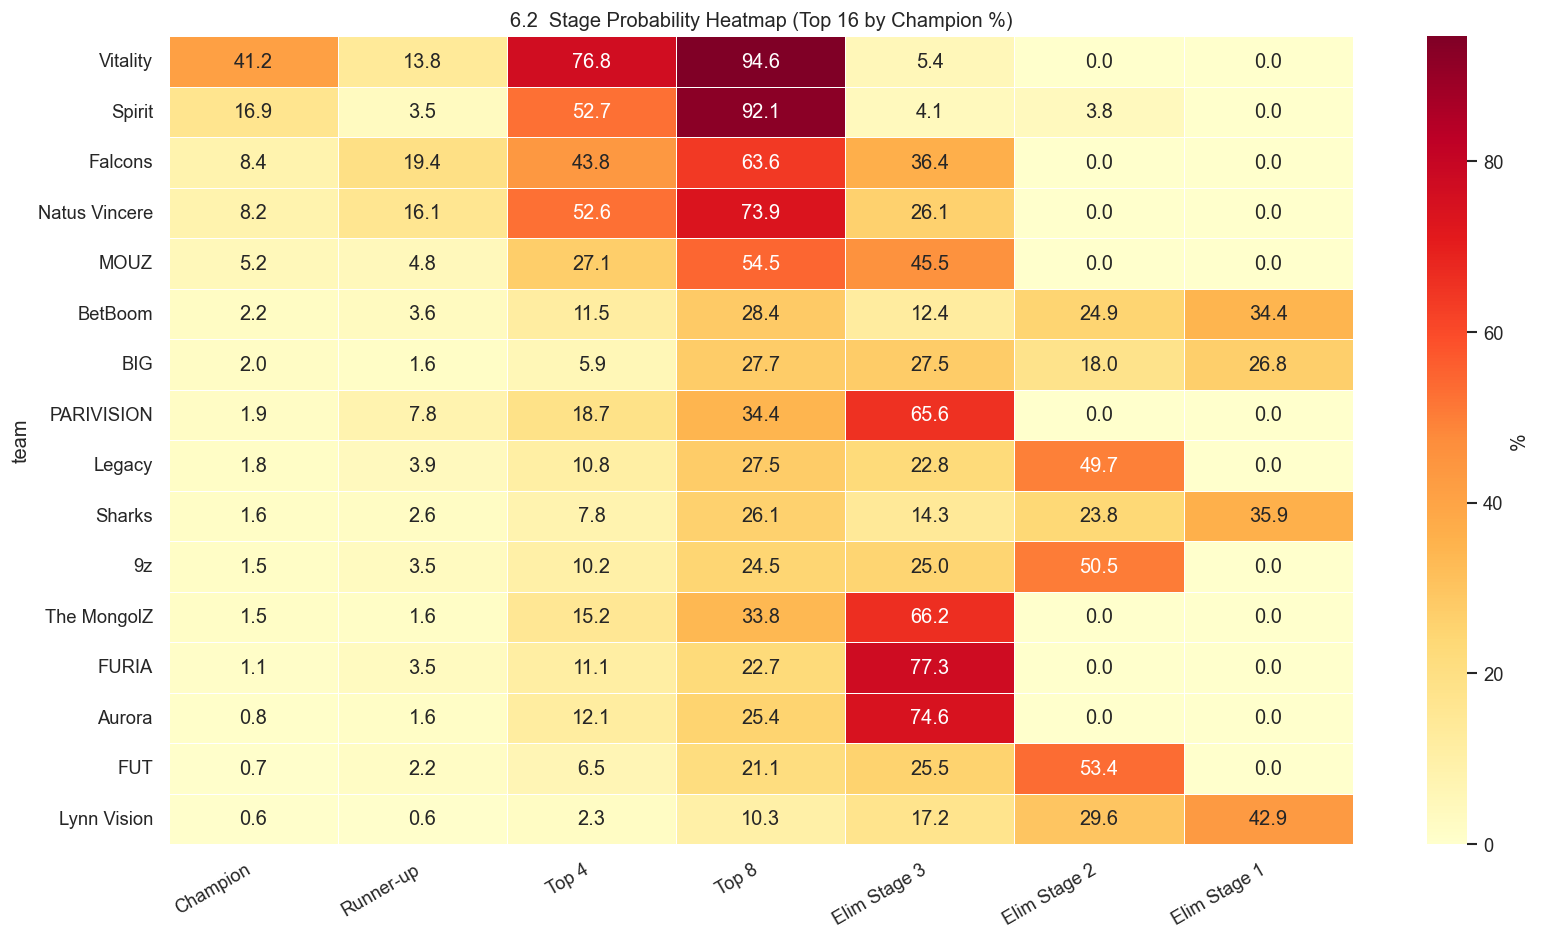

In [27]:
if odds_path.exists():
    stage_cols   = ["champion_pct", "runner_up_pct", "top4_pct", "top8_pct",
                    "elim_stage3_pct", "elim_stage2_pct", "elim_stage1_pct"]
    heatmap_data = odds_sorted[stage_cols].head(16)

    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(
        heatmap_data,
        annot=True, fmt=".1f", cmap="YlOrRd",
        linewidths=0.4, ax=ax, cbar_kws={"label": "%"},
    )
    ax.set_title("6.2  Stage Probability Heatmap (Top 16 by Champion %)")
    ax.set_xticklabels(
        ["Champion", "Runner-up", "Top 4", "Top 8",
         "Elim Stage 3", "Elim Stage 2", "Elim Stage 1"],
        rotation=30, ha="right",
    )
    plt.tight_layout()
    plt.show()

### 6.3 Stage Breakdown — All Teams (Stacked Bar)

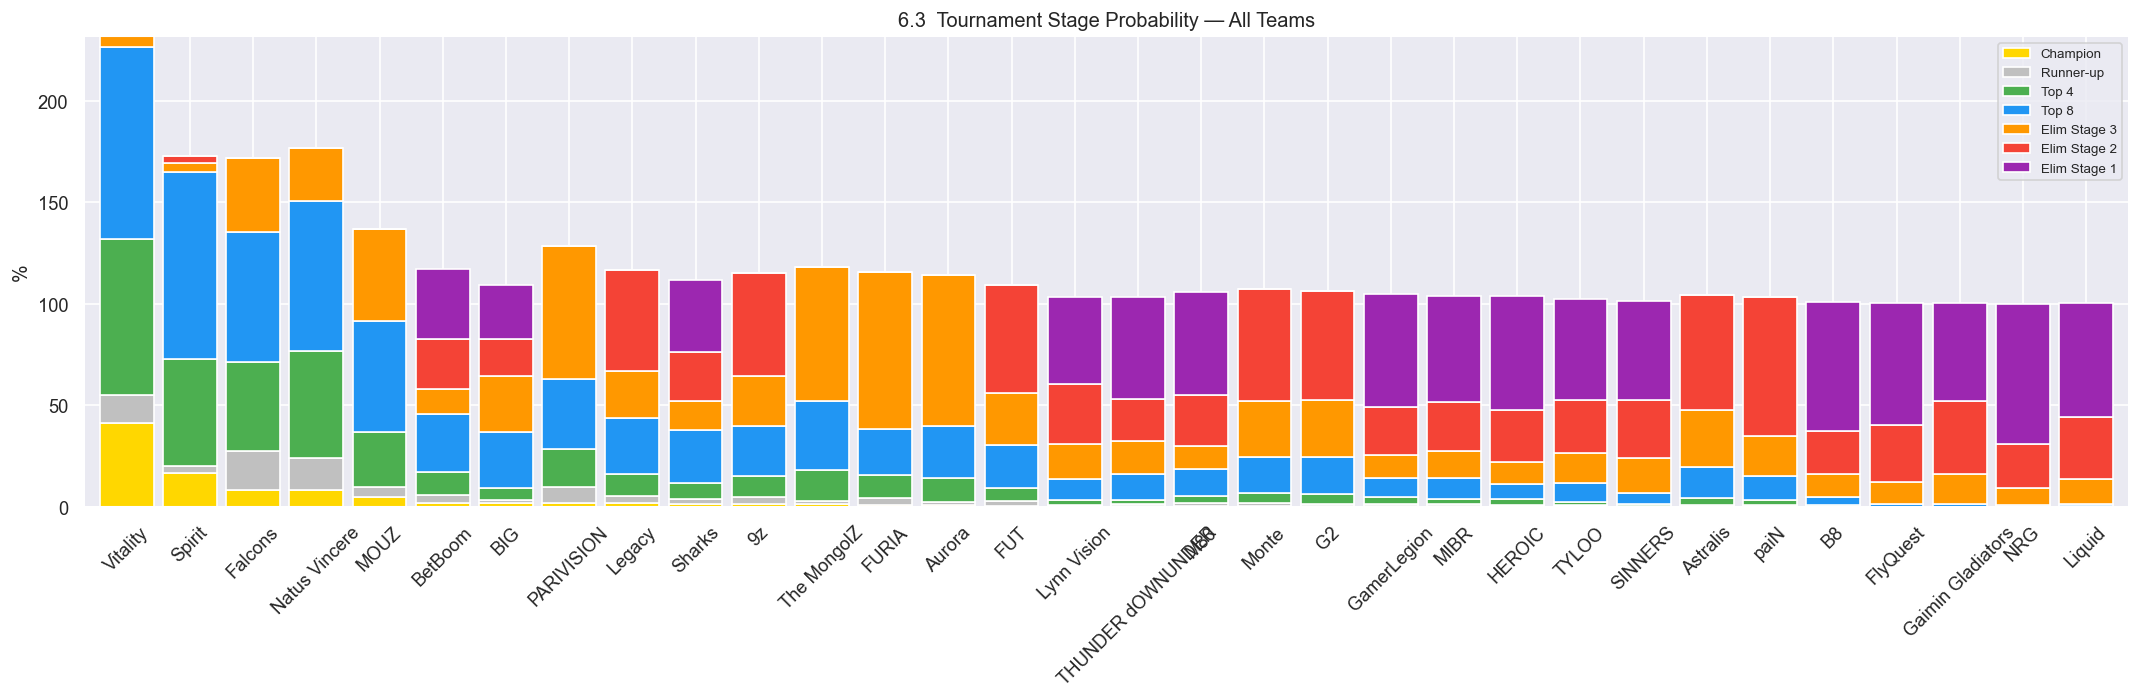

In [28]:
if odds_path.exists():
    stage_order  = ["champion_pct", "runner_up_pct", "top4_pct", "top8_pct",
                    "elim_stage3_pct", "elim_stage2_pct", "elim_stage1_pct"]
    stage_labels = ["Champion", "Runner-up", "Top 4", "Top 8",
                    "Elim Stage 3", "Elim Stage 2", "Elim Stage 1"]
    colors_stack = ["gold", "silver", "#4CAF50", "#2196F3",
                    "#FF9800", "#F44336", "#9C27B0"]

    ax = odds_sorted[stage_order].plot(
        kind="bar", stacked=True, figsize=(18, 6),
        color=colors_stack, width=0.85,
    )
    ax.set_title("6.3  Tournament Stage Probability — All Teams")
    ax.set_ylabel("%")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(stage_labels, loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 7. Pick'Em Optimizer — Opening Stage

Runs the Stage 1 Swiss simulation and finds the pick set maximising P(>=5 correct).

### 7.1 Marginal Outcome Probabilities · 7.2 Optimal Pick Set · 7.3 Score Distribution

In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

from o1_config import STAGE1_TEAMS
from o7_simulate import precompute_win_probs, fetch_all_team_stats
from o8_pickem import run_simulations, optimize_pickem, score_distribution

PICKEM_N_SIMS = 50_000

pickem_teams = list(STAGE1_TEAMS)
print(f"Stage 1 teams ({len(pickem_teams)}): {pickem_teams}")

# Pairwise win probabilities (GPU batch if available)
pickem_team_dfs = fetch_all_team_stats(teams=pickem_teams)
pickem_probs    = precompute_win_probs(
    pickem_teams, pickem_team_dfs, elo, pt_model, xgb_model,
    scaler, feat_cols, blend_w,
)

# Monte Carlo Swiss simulations
print(f"Running {PICKEM_N_SIMS:,} simulations...")
tz_arr, adv_arr, oz_arr = run_simulations(pickem_teams, pickem_probs, PICKEM_N_SIMS)

# Optimal pick set
best_picks, best_p5 = optimize_pickem(pickem_teams, tz_arr, adv_arr, oz_arr)
pick_dist = score_distribution(best_picks, pickem_teams, tz_arr, adv_arr, oz_arr)

print("\n=== OPTIMAL PICK'EM ===")
print(f"  3-0  : {best_picks['three_zero']}")
print(f"  Adv  : {best_picks['advance']}")
print(f"  0-3  : {best_picks['zero_three']}")
print(f"  P(>=5 correct): {sum(v for k,v in pick_dist.items() if k>=5):.1%}")

In [ ]:
# 7.1 Marginal outcome probabilities
p30  = tz_arr.mean(0)
padv = adv_arr.mean(0)
p03  = oz_arr.mean(0)

x     = np.arange(len(pickem_teams))
width = 0.28

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width, p30,  width, label="P(3-0)",    color="#4CAF50", alpha=0.9)
ax.bar(x,         padv, width, label="P(advance)", color="#2196F3", alpha=0.9)
ax.bar(x + width, p03,  width, label="P(0-3)",    color="#F44336", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(pickem_teams, rotation=40, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("7.1  Stage 1 Marginal Outcome Probabilities (Monte Carlo)")
ax.set_ylabel("Probability")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 7.2 Optimal pick set — highlighted table
team_idx = {t: i for i, t in enumerate(pickem_teams)}

rows = []
for t in pickem_teams:
    i = team_idx[t]
    slot = (
        "3-0"     if t in best_picks["three_zero"] else
        "Advance" if t in best_picks["advance"]    else
        "0-3"     if t in best_picks["zero_three"] else
        ""
    )
    rows.append({
        "Team":    t,
        "Slot":    slot,
        "P(3-0)":  f"{p30[i]:.1%}",
        "P(adv)":  f"{padv[i]:.1%}",
        "P(0-3)":  f"{p03[i]:.1%}",
    })

pick_df = pd.DataFrame(rows).set_index("Team")

slot_colors = {"3-0": "#C8E6C9", "Advance": "#BBDEFB", "0-3": "#FFCDD2", "": "white"}

def highlight_slot(row):
    color = slot_colors.get(row["Slot"], "white")
    return [f"background-color: {color}"] * len(row)

print("7.2  Optimal Pick Set  —  P(>=5 correct) = {:.1%}".format(best_p5))
pick_df.style.apply(highlight_slot, axis=1)

In [ ]:
# 7.3 Score distribution
ks   = list(range(11))
vals = [pick_dist[k] for k in ks]

bar_colors = [
    "#F44336" if k < 4 else
    "#FF9800" if k < 5 else
    "#4CAF50"
    for k in ks
]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(ks, vals, color=bar_colors, edgecolor="white", linewidth=0.6)
ax.bar_label(bars, fmt=lambda v: f"{v:.1%}" if v > 0.005 else "", padding=3, fontsize=9)

ax.axvline(4.5, color="orange", linestyle="--", linewidth=1.2, label=">=5 threshold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(ks)
ax.set_xlabel("Correct picks out of 10")
ax.set_ylabel("Probability")
ax.set_title(
    "7.3  Score Distribution — Optimal Pick Set\n"
    f"P(>=5) = {sum(v for k,v in pick_dist.items() if k>=5):.1%}  |  "
    f"E[correct] = {sum(k*v for k,v in pick_dist.items()):.2f}"
)
ax.legend()
plt.tight_layout()
plt.show()